In [16]:
import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from datetime import datetime

In [2]:
wb.source.info()

id,name,code,concepts,lastupdated
1,Doing Business,DBS,3,2021-08-18
2,World Development Indicators,WDI,3,2026-02-24
3,Worldwide Governance Indicators,WGI,3,2026-03-18
5,Subnational Malnutrition Database,SNM,3,2016-03-21
6,International Debt Statistics,IDS,4,2025-12-03
11,Africa Development Indicators,ADI,3,2013-02-22
12,Education Statistics,EDS,3,2024-06-25
13,Enterprise Surveys,ESY,3,2022-03-25
14,Gender Statistics,GDS,3,2026-03-03
15,Global Economic Monitor,GEM,3,2025-12-17


In [11]:
wb_source_list = wb.source.list()

for src in wb_source_list:
    updated = datetime.strptime(src["lastupdated"], "%Y-%m-%d")
    if updated >= datetime(2026, 1, 1):
        print(f"{src['id']:>3} {src['lastupdated']} [{src['code']}] {src['name']}")

  2 2026-02-24 [WDI] World Development Indicators
  3 2026-03-18 [WGI] Worldwide Governance Indicators
 14 2026-03-03 [GDS] Gender Statistics
 16 2026-02-02 [HNP] Health Nutrition and Population Statistics
 20 2026-02-03 [PSD] Quarterly Public Sector Debt
 22 2026-01-30 [QDS] Quarterly External Debt Statistics SDDS
 23 2026-01-30 [QDG] Quarterly External Debt Statistics GDDS
 27 2026-01-13 [GEP] Global Economic Prospects
 68 2026-01-21 [PF6] PEFA 2016
 70 2026-01-20 [EF2] Economic Fitness 2
 84 2026-02-19 [EDP] Education Policy
 91 2026-01-21 [CRP] PEFA_CRPFM


In [17]:
# NY.GDP.MKTP.CD = GDP (current US$)
df = wb.data.DataFrame(
    "NY.GDP.MKTP.CD",
    economy=["KOR", "USA", "JPN"],
    time=range(2010, 2024),     # 2010 ~ 2023
)
 
print("── 원본 DataFrame ──")
print(df)
print()

── 원본 DataFrame ──
               YR2010        YR2011        YR2012        YR2013        YR2014  \
economy                                                                         
JPN      5.759072e+12  6.233147e+12  6.272363e+12  5.212328e+12  4.896994e+12   
KOR      1.192830e+12  1.307103e+12  1.335344e+12  1.434670e+12  1.556252e+12   
USA      1.504896e+13  1.559973e+13  1.625397e+13  1.684319e+13  1.755068e+13   

               YR2015        YR2016        YR2017        YR2018        YR2019  \
economy                                                                         
JPN      4.444931e+12  5.003678e+12  4.930837e+12  5.040881e+12  5.117994e+12   
KOR      1.539212e+12  1.579151e+12  1.710197e+12  1.824251e+12  1.751046e+12   
USA      1.820602e+13  1.869511e+13  1.947734e+13  2.053306e+13  2.138098e+13   

               YR2020        YR2021        YR2022        YR2023  
economy                                                          
JPN      5.054068e+12  5.039148e+12  

In [18]:
df = df.T                         # 행↔열 전환
df.index = df.index.str.replace("YR", "").astype(int)  # 'YR2010' → 2010
df.index.name = "Year"
df = df / 1e12                    # 달러 → 조 달러(trillion) 단위 변환
df = df.sort_index()              # 연도 오름차순 정렬
 
# 열 이름을 보기 좋게 변경
df.rename(columns={
    "KOR": "South Korea",
    "USA": "United States",
    "JPN": "Japan",
}, inplace=True)
 
print("── 전처리 후 DataFrame (단위: 조 달러) ──")
print(df.round(2))
print()

── 전처리 후 DataFrame (단위: 조 달러) ──
economy  Japan  South Korea  United States
Year                                      
2010      5.76         1.19          15.05
2011      6.23         1.31          15.60
2012      6.27         1.34          16.25
2013      5.21         1.43          16.84
2014      4.90         1.56          17.55
2015      4.44         1.54          18.21
2016      5.00         1.58          18.70
2017      4.93         1.71          19.48
2018      5.04         1.82          20.53
2019      5.12         1.75          21.38
2020      5.05         1.74          21.06
2021      5.04         1.94          23.32
2022      4.26         1.80          25.60
2023      4.21         1.84          27.29



In [19]:
try:
    plt.rcParams["font.family"] = "Malgun Gothic"
except Exception:
    try:
        plt.rcParams["font.family"] = "AppleGothic"
    except Exception:
        plt.rcParams["font.family"] = "NanumGothic"
 
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 깨짐 방지

In [20]:
# 색상 지정
colors = {
    "United States": "#3266ad",
    "Japan":         "#D85A30",
    "South Korea":   "#1D9E75",
}

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

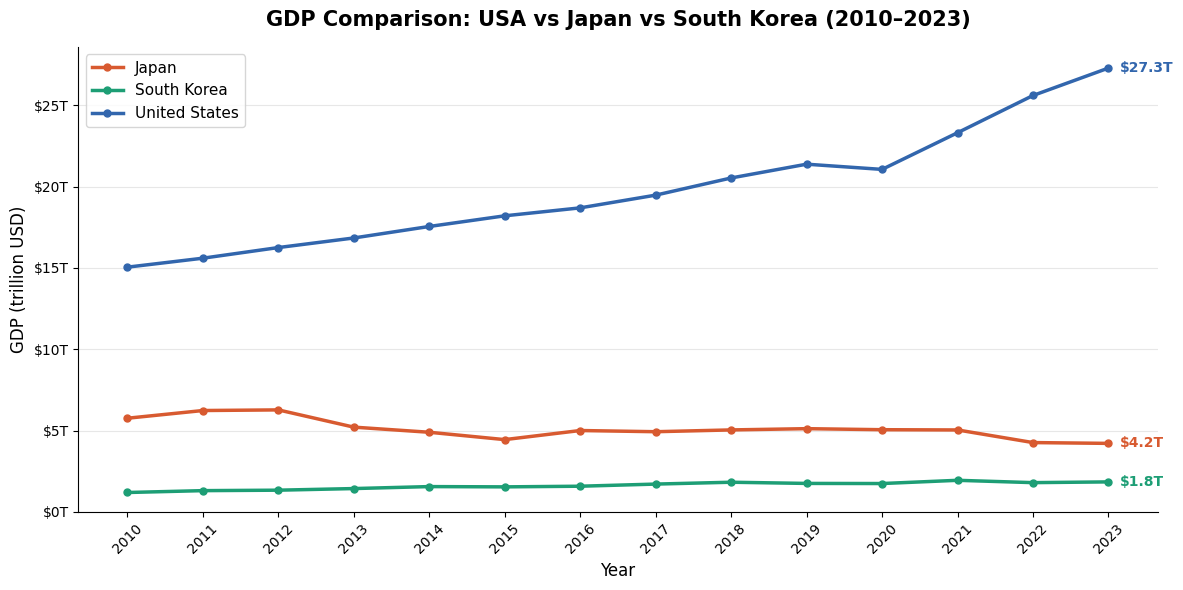

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
 
for country in df.columns:
    ax.plot(
        df.index,
        df[country],
        marker="o",
        markersize=5,
        linewidth=2.5,
        label=country,
        color=colors.get(country),
    )
    # 마지막 값 라벨 표시
    last_year = df.index[-1]
    last_val = df[country].iloc[-1]
    ax.annotate(
        f"${last_val:.1f}T",
        xy=(last_year, last_val),
        xytext=(8, 0),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color=colors.get(country),
        va="center",
    )
 
# 축 설정
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("GDP (trillion USD)", fontsize=12)
ax.set_title(
    "GDP Comparison: USA vs Japan vs South Korea (2010–2023)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xticks(df.index)
ax.set_xticklabels(df.index, rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}T"))
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
 
plt.tight_layout()
plt.show()